In [ ]:
!git clone https://github.com/jeminanda/hometrainer.git

In [ ]:
!pip install kagglehub

In [ ]:
import os
import shutil
import kagglehub

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# hometrainer/src/preprocessing 경로에서 모듈 불러오기
from src.preprocessing import (
    normalize_landmarks,
    calculate_angle,
    slice_repetitions,
    animate_skeleton_2d
)

# 데이터셋 경로 지정
RAW_DATA_DIR = os.path.join("hometrainer", "data", "raw")

In [ ]:
import numpy as np
from src.preprocessing import normalize_landmarks  # 경로에 맞춰 import

# 1. 파일 경로 지정 및 .npy 파일 로드
npy_path = "data/raw/sample_exercise_keypoints1.npy"
sample_keypoints_npy = np.load(npy_path)

# 2. 로드된 데이터 Shape 확인 (Shape: (T, J, C))
print(f"로드된 원본 키포인트 Shape: {sample_keypoints_npy.shape}")

# 3. src.preprocessing.normalize_landmarks 모듈 적용
normalized_landmarks_array = normalize_landmarks(sample_keypoints_npy)

# 4. 결과 출력
print(f"정규화된 3D 랜드마크 shape: {normalized_landmarks_array.shape}")
print(f"정규화된 3D 랜드마크 sample: {normalized_landmarks_array[15]}")

로드된 원본 키포인트 Shape: (135, 33, 3)
정규화된 3D 랜드마크 shape: (135, 33, 3)
정규화된 3D 랜드마크 sample: [[ 1.3439953   0.0725453   0.9999473 ]
 [ 1.4017435  -0.02739228  0.9998805 ]
 [ 1.4006722  -0.04380269  0.99989134]
 [ 1.3994145  -0.06326859  0.9999115 ]
 [ 1.4025044  -0.03918953  0.99991643]
 [ 1.4019144  -0.06247433  0.9999402 ]
 [ 1.4014121  -0.08939808  0.9999513 ]
 [ 1.3569978  -0.22271079  0.999811  ]
 [ 1.3589714  -0.22963662  0.9999437 ]
 [ 1.2660041   0.02956669  0.99986786]
 [ 1.2653267   0.01466739  0.9999218 ]
 [ 0.91626436 -0.29715726  0.9993091 ]
 [ 1.0146797  -0.13292125  0.99998194]
 [ 0.863371    0.6645457   0.38380027]
 [ 0.9587209   0.84646976  0.99730515]
 [ 0.87310755  1.4491      0.5777107 ]
 [ 0.9935222   1.8373287   0.99621856]
 [ 0.9496473   1.4826382   0.56990397]
 [ 1.1276728   1.9381887   0.9932481 ]
 [ 0.9752132   1.5294234   0.57740235]
 [ 1.1439747   1.89994     0.99138033]
 [ 0.9431761   1.5480249   0.57366663]
 [ 1.0906311   1.8747689   0.98333466]
 [-0.00206124 -0.

Squat Animation Generating...
2D 애니메이션 저장 중: squat_animation.gif ...
저장 완료!


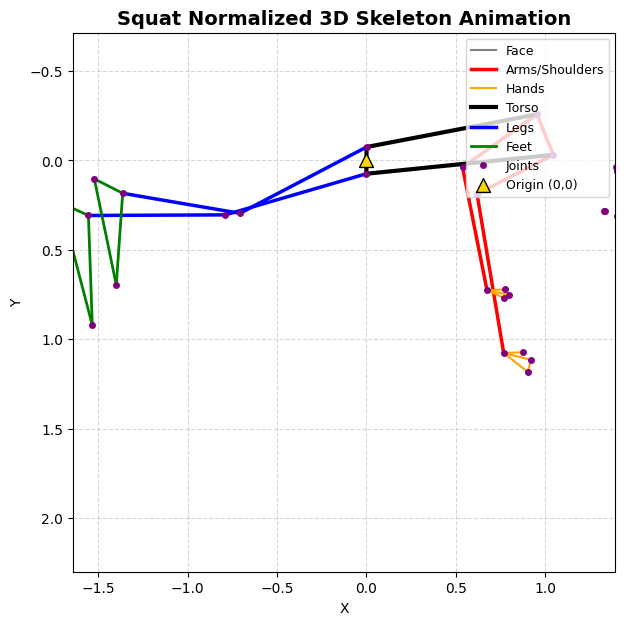

In [3]:
# notebook에서 matplotlib 애니메이션을 표시하기 위한 설정 (선택사항)
# %matplotlib notebook # 또는 %matplotlib inline (애니메이션 표시에 jshtml 방식 사용 시)

import matplotlib as mpl

# Notebook에서 jshtml 방식으로 애니메이션을 볼 때 필요한 설정 (가끔 주석 처리해야 작동하기도 함)
# mpl.rc('animation', html='jshtml')

# Cell 3에서 정규화 완료된 'normalized_landmarks_array' 사용

# 1. 시각화할 프레임 시퀀스 선택 (예: 스쿼트 동작이 포함된 연속된 90프레임)
# 실제 데이터의 시퀀스 ID 등을 기준으로 끊어서 사용해야 함
squat_idx = 0
animation_sequence = normalized_landmarks_array[squat_idx:squat_idx+100] # 90프레임 시퀀스 예시

# 2. 3D 스켈레톤 애니메이션 생성
print("Squat Animation Generating...")
squat_ani = animate_skeleton_2d(
    animation_sequence, 
    save_path="squat_animation.gif", # GIF로 저장하려면 주석 해제 (저장 안 하려면 None)
    title=f"Squat Normalized 3D Skeleton Animation"
)

# Notebook에서 애니메이션 객체를 반환하여 표시
# 만약 `plot_skeleton_3d` 내부에서 `plt.show()`를 호출하지 않았고, 
# Notebook 설정을 마쳤다면 아래 줄만으로 애니메이션이 재생됨
squat_ani

In [ ]:
import mediapipe as mp
mp.__version__

In [ ]:
# 1. 필요 패키지 설치
!pip install mediapipe opencv-python numpy matplotlib

# 2. MediaPipe Pose Task 모델 다운로드 (프로젝트 루트의 models 디렉터리에 저장)
!mkdir -p models
!curl -L -o models/pose_landmarker_full.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task

In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 프로젝트 루트 경로를 sys.path에 추가 (ipynb 위치에 따라 조정)
# 현재 노트북이 notebooks/ 폴더 안에 있다면 '..'으로 루트를 지정합니다.
project_root = Path(".").resolve()  # 필요시 Path("../").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from hometrainer.src.pose_extraction import BlazePoseExtractor, ExtractionConfig, PoseNotDetectedError

# -------------------------------------------------------------
# 1. 설정 생성 (3D 좌표 x, y, z, visibility 모두 포함 시 include_z=True)
# -------------------------------------------------------------
config = ExtractionConfig(
    model_path="models/pose_landmarker_full.task",
    include_z=False,            # (x, y, visibility) -> shape (T, 33, 3)
    target_fps=None,            # None이면 원본 FPS 유지
    min_detected_ratio=0.1      # 전체 프레임 중 최소 10%는 검출되어야 함
)

input_video_path = "data/raw/Pushup2.mp4"  # 추출할 영상 경로
output_npy_path = "data/raw/sample_exercise_keypoints2.npy"

# -------------------------------------------------------------
# 2. 키포인트 추출 실행
# -------------------------------------------------------------
try:
    with BlazePoseExtractor(config) as extractor:
        print(f"[{input_video_path}] 키포인트 추출 시작...")
        keypoints, meta = extractor.extract_from_video(input_video_path)

    print("\n✅ 추출 완료!")
    print(f"- 키포인트 배열 Shape (T, J, C): {keypoints.shape}")
    print(f"- 메타데이터: {meta}")

    # -------------------------------------------------------------
    # 3. 데이터 (.npy) 저장
    # -------------------------------------------------------------
    save_path = Path(output_npy_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(save_path, keypoints)
    print(f"- .npy 저장 완료: {save_path.resolve()}")

except PoseNotDetectedError as e:
    print(f"❌ 포즈 검출 실패: {e}")
except FileNotFoundError as e:
    print(f"❌ 파일을 찾을 수 없습니다: {e}")

In [ ]:
# 저장한 .npy 불러오기 검증
loaded_kps = np.load(output_npy_path)

print(f"로드된 데이터 Shape: {loaded_kps.shape}")

# 첫 번째 프레임(T=0)의 코(Nose, Index 0), 왼쪽 무릎(Left Knee, Index 25) 좌표 출력
# BlazePose 키포인트 Index: 0(Nose), 11/12(Shoulders), 23/24(Hips), 25/26(Knees), 27/28(Ankles)
first_frame = loaded_kps[0]
print("\n[프레임 0 주요 관절 좌표 (x, y, visibility)]")
print(f"- Nose (0): {first_frame[0]}")
print(f"- Left Knee (25): {first_frame[25]}")

# 시간(T) 흐름에 따른 오른쪽 무릎(Right Knee, Index 26) Y 좌표 변화 시각화 (스쿼트/운동 템포 확인)
plt.figure(figsize=(10, 4))
plt.plot(loaded_kps[:, 26, 1], label="Right Knee Y-coord (Normalized)", color="red")
plt.gca().invert_yaxis()  # 이미지 좌표계는 위쪽이 0이므로 Y축 반전
plt.title("Right Knee Y Coordinate Trajectory Across Frames")
plt.xlabel("Frame Index (T)")
plt.ylabel("Y Position")
plt.grid(True)
plt.legend()
plt.show()